In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from distributed import Client,LocalCluster
import time
from scipy import ndimage
import matplotlib.colors
import os
from matplotlib.colors import TwoSlopeNorm

import datetime

In [16]:
cluster = LocalCluster()         
client = cluster.get_client()
print(cluster.get_client)

dir_data = r"C:\Users\ls2236\Projects\BIG\ERA5\arco-era5\data"



<bound method Cluster.get_client of LocalCluster(a6d8def9, 'tcp://127.0.0.1:60363', workers=6, threads=24, memory=63.25 GiB)>


2024-10-16 11:31:45,544 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:60396 (pid=7112) exceeded 95% memory budget. Restarting...
2024-10-16 11:31:45,587 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:60396' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('getitem-c0d06c763107fc1273e1b7f744eef758', 0, 66, 0, 0), ('getitem-c0d06c763107fc1273e1b7f744eef758', 0, 60, 0, 0), ('getitem-c0d06c763107fc1273e1b7f744eef758', 0, 77, 0, 0), ('getitem-c0d06c763107fc1273e1b7f744eef758', 0, 81, 0, 0), ('getitem-c0d06c763107fc1273e1b7f744eef758', 0, 71, 0, 0)} (stimulus_id='handle-worker-cleanup-1729092705.586897')
2024-10-16 11:31:46,400 - distributed.nanny - WARNING - Restarting worker
2024-10-16 11:31:47,282 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:60399 (pid=12836) exceeded 95% memory budget. Restarting...
2024-10-16 11:31:47,299 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:6

In [17]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 24,Total memory: 63.25 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:60363,Workers: 6
Dashboard: http://127.0.0.1:8787/status,Total threads: 24
Started: Just now,Total memory: 63.25 GiB
Comm: tcp://127.0.0.1:60403,Total threads: 4
Dashboard: http://127.0.0.1:60407/status,Memory: 10.54 GiB
Nanny: tcp://127.0.0.1:60366,


In [4]:
dir_data = r"C:\Users\ls2236\Projects\BIG\ERA5\arco-era5\data\daily"
   
ncdata_full = xr.open_mfdataset(os.path.join(dir_data,"*.nc"))


In [5]:
ncdata_full

<xarray.Dataset> Size: 30GB
Dimensions:       (time: 30316, latitude: 281, longitude: 441)
Coordinates:
  * latitude      (latitude) float32 1kB 90.0 89.75 89.5 ... 20.5 20.25 20.0
  * longitude     (longitude) float32 2kB -150.0 -149.8 -149.5 ... -40.25 -40.0
  * time          (time) datetime64[ns] 243kB 1940-01-01 ... 2022-12-31
Data variables:
    daily_t2_max  (time, latitude, longitude) float32 15GB dask.array<chunksize=(366, 281, 441), meta=np.ndarray>
    daily_t2_min  (time, latitude, longitude) float32 15GB dask.array<chunksize=(366, 281, 441), meta=np.ndarray>

In [144]:

def load_data(dir_data):

    ncdata_full = xr.open_mfdataset(os.path.join(dir_data,"*.nc"))
    ncdata_var = ncdata_full["daily_t2_min"]
    return(ncdata_var)

def calc_stats(ncdata):

    tmean_season = ncdata.groupby("time.season").mean(dim='time').persist()
    tmean_season_std = ncdata.groupby("time.season").std(dim='time').persist()
    anomaly = (t2min_raw - tmean_season.sel(season='DJF')).persist()
    standard_anomaly =anomaly/tmean_season_std.sel(season='DJF').persist()
    return(standard_anomaly,tmean_season_std,anomaly)

t2min_raw = load_data(os.path.join(dir_data,"daily"))

standard_anomaly,tmean_season_std,anomaly = calc_stats(t2min_raw)
cao_bool = standard_anomaly.where(tmean_season_std.sel(season='DJF') > 3,0)
cao_bool = cao_bool < -1.75

2024-10-15 14:10:52,250 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'original-open_dataset-daily_t2_min-68a200bb07a65c4d661a657d43618ab9' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x000002ADBAD27920>, (ImplicitToExplicitIndexingAdapter(array=CopyOnWriteArray(array=LazilyIndexedArray(array=<xarray.backends.netCDF4_.NetCDF4ArrayWrapper object at 0x000002ADC29E2D00>, key=BasicIndexer((slice(None, None, None), slice(None, None, None), slice(None, None, None)))))),), {})
new run_spec: (<function execute_task at 0x000002ADBAD27920>, (ImplicitToExplicitIndexingAdapter(

In [145]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["purple","darkblue","blue","lightblue","white","lightcoral","red","darkred","pink"])
z = [-35,-30,-25,-20,-15,-10,-5,0,1,10,20,50]
norm = TwoSlopeNorm(vmin=np.min(z), vcenter=0, vmax=np.max(z))

In [146]:
date_i=datetime.date(1982,1,8)
date_f=datetime.date(1982,1,14)
N=date_f-date_i
N=N.days+1
date_list = [date_i + datetime.timedelta(days=x) for x in range(N)]


In [147]:
data_array = cao_bool.sel(time=slice(date_i,date_f))
data_array_anom = anomaly.sel(time=slice(date_i,date_f))
time = data_array["time"].values
latitude = data_array["latitude"].values
longitude = data_array["longitude"].values
data = np.random.randint(0, 2, size=(len(time), len(latitude), len(longitude)))


In [148]:
save_path = "results/live_tracker"

In [149]:
def process_time_slice_and_plot(time_slice, anom_slice,time_coord, lat_vals, lon_vals, size_threshold=1000):

    labeled_slice, num_features = ndimage.label(time_slice.values)
    region_sizes = np.bincount(labeled_slice.ravel())
    region_sizes[0] = 0  # Ignore background
    largest_region_label = np.argmax(region_sizes)
    largest_region_size = region_sizes[largest_region_label]
    if largest_region_size >= size_threshold:
        if len(region_sizes) > 1:
            labs = np.argwhere(region_sizes>size_threshold)
            lab_list = []
            for lab in labs:
                lab_list.append([anom_slice.where(labeled_slice == lab).quantile(0.25).values])
            print(lab_list)
            largest_region_label = labs[np.argmin(lab_list)]
            largest_region_size = region_sizes[largest_region_label]
            
        temp_array = xr.DataArray(labeled_slice,coords={"latitude": time_slice["latitude"].values,"longitude": time_slice["longitude"].values},dims=['latitude','longitude'])
        temp2=anom_slice.where(labeled_slice == largest_region_label,0)
        anom_min=anom_slice.where(labeled_slice == largest_region_label,0).min().values
        anom_mean=anom_slice.where(labeled_slice == largest_region_label,0).mean().values
        anom_min_all=anom_slice.min().values
        com = ndimage.center_of_mass(np.abs(temp2.values))
        #com = ndimage.center_of_mass(temp2.values)
        com_lat = lat_vals[int(com[0])]
        com_lon = lon_vals[int(com[1])]
        # Plot the result
        plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        plt.contourf(lon_vals, lat_vals, anom_slice,cmap=cmap,norm=norm,levels=z,extend="both")
        plt.contour(lon_vals, lat_vals, temp_array,colors="red")
        plt.contour(lon_vals, lat_vals, temp_array.where(labeled_slice != largest_region_label),colors="black")
        plt.scatter(com_lon, com_lat, color='yellow', marker='x', label='Center of Mass')
        ax.coastlines( edgecolor='gray', linewidth=0.5)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
        #filename=pd.to_datetime(str(time[t_idx])).strftime("%Y%m%d") 
        plt.savefig(os.path.join(save_path, f'v2_{str(t_idx.strftime("%Y%m%d"))}.png'))
        plt.close()
        #print(time_coord,com_lat,com_lon)
        return com_lat, com_lon, anom_min, anom_min_all,anom_mean,largest_region_size
    # If no valid region, return NaN
    return np.nan, np.nan, np.nan, np.nan, np.nan,np.nan

In [150]:
my_list = []
for t_idx in date_list:
    time_slice = data_array.sel(time=t_idx.strftime("%Y-%m-%d"))
    anom_slice = data_array_anom.sel(time=t_idx.strftime("%Y-%m-%d"))
    time_coord=t_idx
    lat_vals=latitude
    lon_vals= longitude
    size_threshold=1000
    com_lat, com_lon, anom_min, anom_min_all,anom_mean,largest_region_size = process_time_slice_and_plot(time_slice,anom_slice, t_idx, latitude, longitude)
    my_list.append([t_idx,com_lat, com_lon, anom_min, anom_min_all,anom_mean,largest_region_size])
df = pd.DataFrame(my_list,columns=["time","lat","lon","min_rel","min_all","anom_mean","size"])

[[array(-16.71938705)], [array(-20.88789749)], [array(-13.60375977)]]
[[array(-17.32684326)], [array(-19.84120178)]]
[[array(-19.76550293)]]
[[array(-17.64730835)]]
[[array(-12.75831604)]]
[[array(-13.80694962)], [array(-8.82215118)], [array(-15.02806854)]]
[[array(-14.16253662)], [array(-15.25779724)]]


In [151]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

In [152]:
# Update group based on distance
df['distance'] = np.nan
for i in range(1, len(df)):
    # Calculate the distance to the previous row
    distance = haversine(df['lat'].iloc[i], df['lon'].iloc[i],
                         df['lat'].iloc[i-1], df['lon'].iloc[i-1])
    df.loc[i,'distance'] = distance
    #if df.loc[i,'distance'] > 1500:
        #df.loc[i:,'group']=df.loc[i:,'group']+1
        #increment += 1  # Increment if distance exceeds the threshold
        #df['group'] = df['group'] + increment  # Update all groups based on the current increment

df.loc[0,'distance']=0

In [13]:
group = df['lat'] - df['lat'].shift()
group[0]=0
df['lat_diff'] = group

In [153]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["purple","darkblue","blue","lightblue","white","lightcoral","red","darkred","pink"])
z = [-35,-30,-25,-20,-15,-10,-5,0,1,10,20,50]
norm = TwoSlopeNorm(vmin=np.min(z), vcenter=0, vmax=np.max(z))

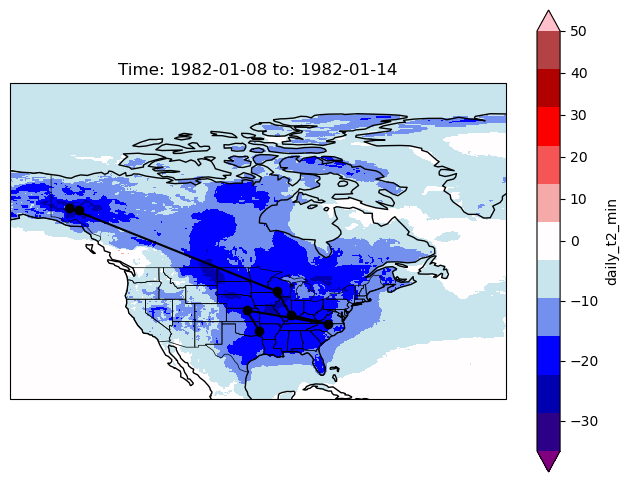

In [154]:
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
anomaly.sel(time=slice(date_i,date_f)).min("time").plot(cmap=cmap,norm=norm,levels=z,extend="both")
plt.plot(df['lon'],df['lat'],'-o',color="black")
plt.title(f'Time: {str(date_i)} to: {date_f}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
ax.coastlines()
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
filename="test"
#plt.savefig(os.path.join(save_path, f'{str(filename)}.png'))
#plt.close()
plt.show()

In [261]:

time_slice = data_array.sel(time=t_idx.strftime("%Y-%m-%d"))
anom_slice = data_array_anom.sel(time=t_idx.strftime("%Y-%m-%d"))
time_coord=t_idx
lat_vals=latitude
lon_vals= longitude
size_threshold=1000


labeled_slice, num_features = ndimage.label(time_slice.values)

region_sizes = np.bincount(labeled_slice.ravel())
region_sizes[0] = 0  # Ignore background
largest_region_label = np.argmax(region_sizes)
largest_region_size = region_sizes[largest_region_label]
labs = np.argwhere(region_sizes>1500)
temp_array = xr.DataArray(labeled_slice,coords={"latitude": time_slice["latitude"].values,"longitude": time_slice["longitude"].values},dims=['latitude','longitude'])

for lab in labs:
    print(lab,region_sizes[lab],lab,anom_slice.where(labeled_slice == lab).mean().values)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

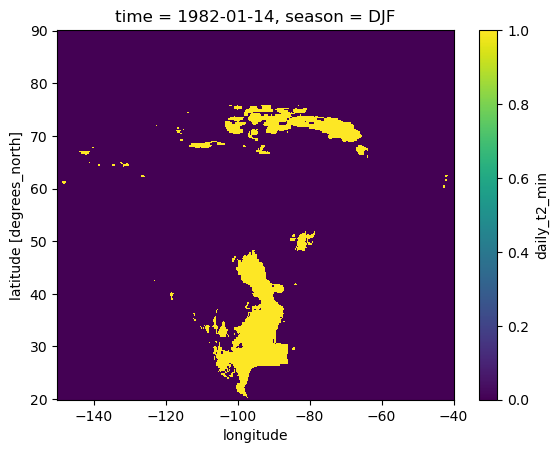

In [156]:
time_slice.plot()

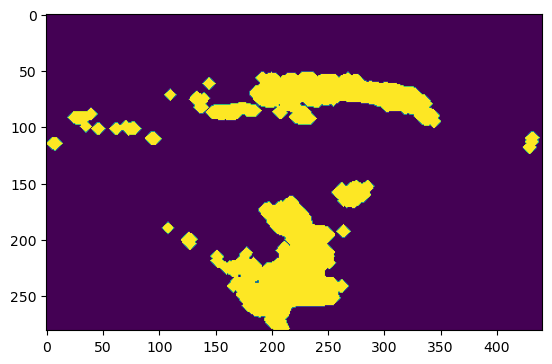

In [157]:
plt.imshow(ndimage.binary_dilation(time_slice.values,iterations=5))

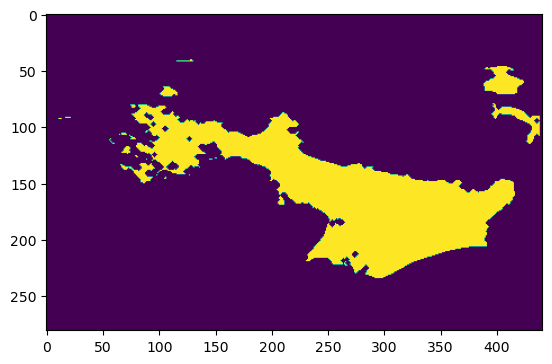

In [27]:
plt.imshow(ndimage.binary_erosion(time_slice.values,iterations=2))

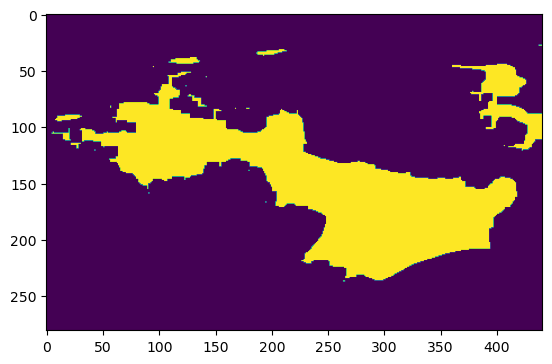

In [26]:
plt.imshow(ndimage.grey_closing(time_slice.values,size=(7,7)))

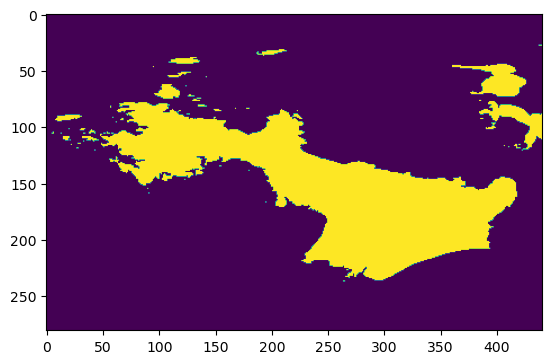

In [25]:
plt.imshow(ndimage.binary_fill_holes(time_slice.values))

In [31]:
stdev_slice=standard_anomaly.sel(time=t_idx.strftime("%Y-%m-%d"))

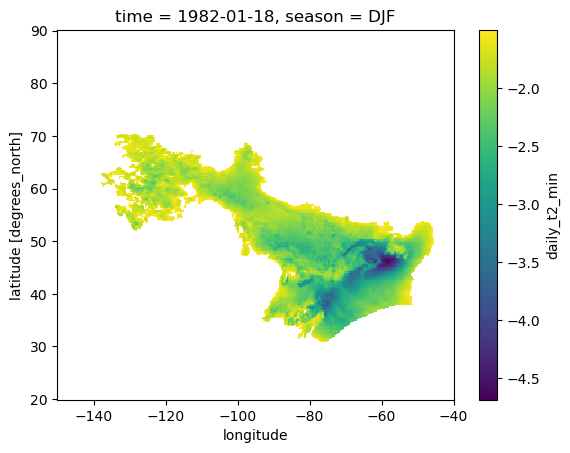

In [34]:
stdev_slice.where(labeled_slice == largest_region_label).plot()

In [353]:
t_idx=datetime.date(1949,1,19)

time_slice = cao_bool.sel(time=t_idx.strftime("%Y-%m-%d"))
anom_slice = anomaly.sel(time=t_idx.strftime("%Y-%m-%d"))
stdev_slice = standard_anomaly.sel(time=t_idx.strftime("%Y-%m-%d"))
time_coord=t_idx
lat_vals=latitude
lon_vals= longitude
size_threshold=1000


labeled_slice, num_features = ndimage.label(time_slice.values)
#labeled_slice = ndimage.binary_fill_holes(labeled_slice)
region_sizes = np.bincount(labeled_slice.ravel())
region_sizes[0] = 0  # Ignore background
largest_region_label = np.argwhere(region_sizes>=size_threshold)
if(np.size(largest_region_label)>0):
    largest_region_size = region_sizes[largest_region_label]
    if len(region_sizes) > 1:
        labs = np.argwhere(region_sizes>=size_threshold)
        lab_list = []
        for lab in labs:
            #labeled_slice = ndimage.binary_fill_holes(anom_slice.where(labeled_slice == lab))
            lab_list.append([anom_slice.where(labeled_slice == lab).quantile(0.5).values])
        print(labs,region_sizes[largest_region_label],lab_list)
        loc = lab_list < lab_list[np.argmax(region_sizes[largest_region_label])]+(region_sizes[largest_region_label] - np.max(region_sizes[largest_region_label]))/5000
        region_info = pd.DataFrame(lab_list,columns=["anomaly"])
        region_info['labs'] = largest_region_label
        region_info['Nsize'] = region_sizes[labs]

        region_info =region_info.loc[loc]
        region_info=region_info.reset_index()
        largest_region_label = region_info['labs'][region_info["anomaly"].argmin()]
        #largest_region_label = labs[loc][np.argmax(region_sizes[labs[loc]])]
        #lab_list = lab_list[loc]
        #labs = labs[loc]
        print(labs,region_sizes[labs],lab_list)
        #largest_region_label = labs[np.argmin(lab_list)]
        largest_region_size = region_sizes[largest_region_label]

[[ 1]
 [ 4]
 [13]
 [38]
 [45]
 [71]
 [93]] [[6896]
 [1075]
 [6422]
 [3458]
 [1053]
 [1569]
 [2595]] [[array(-8.96448517)], [array(-8.17605591)], [array(-14.67939758)], [array(-17.61895752)], [array(-15.22407532)], [array(-14.52380371)], [array(-11.30596924)]]
[[ 1]
 [ 4]
 [13]
 [38]
 [45]
 [71]
 [93]] [[6896]
 [1075]
 [6422]
 [3458]
 [1053]
 [1569]
 [2595]] [[array(-8.96448517)], [array(-8.17605591)], [array(-14.67939758)], [array(-17.61895752)], [array(-15.22407532)], [array(-14.52380371)], [array(-11.30596924)]]


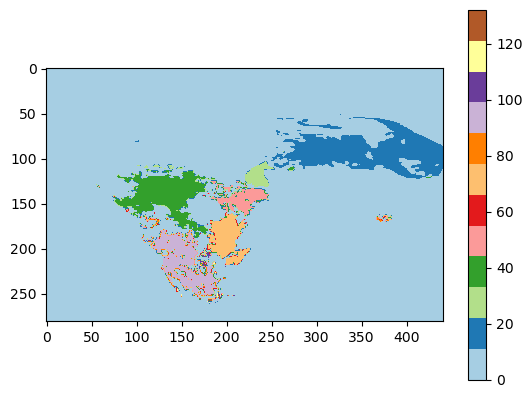

In [354]:
plt.imshow(labeled_slice,cmap="Paired")
plt.colorbar()

In [347]:
#region_info[region_info["anomaly"].argmin(),:]


np.int64(38)

In [302]:
region_info.loc[loc]

,anomaly,labs,Nsize
2,-14.679397583007812,13,6422
3,-17.61895751953125,38,3458
4,-15.224075317382812,45,1053
5,-14.5238037109375,71,1569
6,-11.30596923828125,93,2595


In [290]:
values = [10, 20, 30, 40, 50]
conditions1 = [False, True, True, True, False]
conditions2 = [False, True, True, True, False]
selected_values = [v for v, c1, c2 in zip(values, conditions1, conditions2) if c1 and c2]
selected_values

[30, 40]

In [286]:
selected_values = [v for v, c in zip(lab_list, loc) if c]
selected_values

[[array(-14.67939758)],
 [array(-17.61895752)],
 [array(-15.22407532)],
 [array(-14.52380371)],
 [array(-11.30596924)]]

In [254]:
loc = lab_list < lab_list[np.argmax(region_sizes[labs])]+(region_sizes[labs] - np.max(region_sizes[labs]))/5000
#np.argmax(region_sizes>=size_threshold)
print(labs[loc][np.argmax(region_sizes[labs[loc]])])
print(region_sizes[labs[loc]])

13
[6422 3458 1053 1569 2595]


In [255]:
labs

array([[ 1],
       [ 4],
       [13],
       [38],
       [45],
       [71],
       [93]])

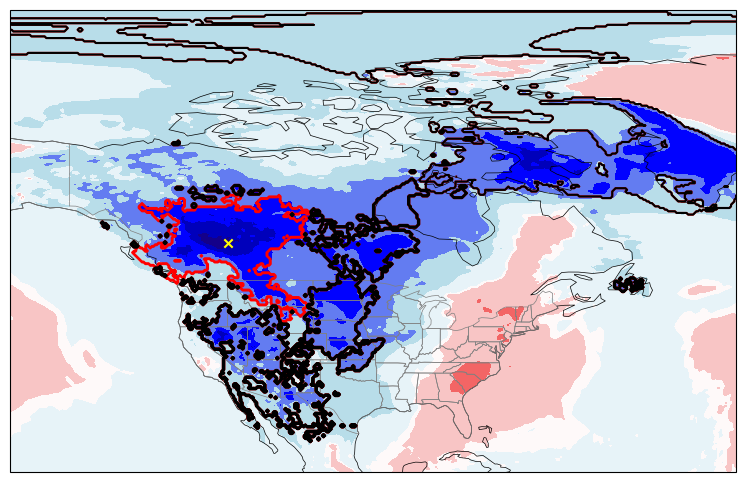

In [355]:
temp_array = xr.DataArray(labeled_slice,coords={"latitude": time_slice["latitude"].values,"longitude": time_slice["longitude"].values},dims=['latitude','longitude'])
temp2=stdev_slice.where(labeled_slice == largest_region_label,0)
anom_min=anom_slice.where(labeled_slice == largest_region_label,0).min().values
anom_mean=anom_slice.where(labeled_slice == largest_region_label,0).mean().values
anom_min_all=anom_slice.min().values
com = ndimage.center_of_mass(np.abs(temp2.values))
#com = ndimage.center_of_mass(temp2.values)
com_lat = lat_vals[int(com[0])]
com_lon = lon_vals[int(com[1])]
# Plot the result
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
plt.contourf(lon_vals, lat_vals, anom_slice,cmap=cmap,norm=norm,levels=z,extend="both")
plt.contour(lon_vals, lat_vals, temp_array,colors="red")
plt.contour(lon_vals, lat_vals, temp_array.where(labeled_slice != largest_region_label),colors="black")
plt.scatter(com_lon, com_lat, color='yellow', marker='x', label='Center of Mass')
ax.coastlines( edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.5)
#filename=pd.to_datetime(str(time[t_idx])).strftime("%Y%m%d") 
#plt.savefig(os.path.join(save_path, f'v2_{str(t_idx.strftime("%Y%m%d"))}.png'))
plt.show()

In [4]:
#Rolling Tracker
dir_data = r"C:\Users\ls2236\Projects\BIG\ERA5\arco-era5\data\daily"
ncdata_full = xr.open_mfdataset(os.path.join(dir_data,"*.nc"))
ncdata_var = ncdata_full["daily_t2_min"]

In [12]:
ncdata_var["dayofyear"] = ncdata_var.time.dt.dayofyear

In [14]:
rolling_stdev = xr.open_dataset(r"C:\Users\ls2236\Projects\CAO_TRACKER\data\statistics_and_transformed\Rolling_daily_stdev.nc")
rolling_mean = xr.open_dataset(r"C:\Users\ls2236\Projects\CAO_TRACKER\data\statistics_and_transformed\Rolling_daily_mean.nc")

In [19]:
save_path = r"C:\Users\ls2236\Projects\CAO_TRACKER\data\statistics_and_transformed"

In [ ]:
anomaly = (ncdata_var - rolling_mean["daily_t2_min"]).to_netcdf(os.path.join(save_path, 'Rolling_daily_anomaly.nc'),compute=True)


In [23]:
anomaly.to_netcdf(os.path.join(save_path, 'Rolling_daily_anomaly.nc'),compute=True)

KilledWorker: Attempted to run task ('sub-c6ce948402db76c312c33e2676631f1d', 19, 0, 0, 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:60550. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [ ]:
standard_anomaly = (anomaly/rolling_stdev).persist()